# Whitening exploration

This notebook walks through **PCA whitening** on a single ECoG session and highlights a subtle but important point: **whitening is fit on the training split**, so the training data can look “perfectly” whitened while **validation (and test) data need not match that geometry**.

We compare:

- **Training vs. validation** after a whitening transform learned from training only  
- **Covariance structure** of the whitened features on each split  
- A **second PCA** on the already-whitened data: on training, explained variance is flat by construction; on validation, it typically is not—showing **domain shift** between splits in the whitened space

Understanding this gap matters whenever whitening or similar **learned preprocessing** is used: good in-sample whitening does not guarantee the same uncorrelated, unit-variance structure on held-out time.


In [ ]:
import os
import h5py
from temporaldata import Data

import numpy as np

from sklearn.decomposition import PCA

from auditorydecoding.plotting import plot_pca_variance, plot_signal, plot_covariance, animate_pca_timeseries

In [186]:
DATA_ROOT = "../data/processed/neurosoft_minipigs_2026"
RECORDING_ID = "sub-02_ses-01_task-AcousStim_acq-LH_desc-filtered"

path = os.path.join(DATA_ROOT, RECORDING_ID + ".h5")

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

CHANNEL_NAMES = data.channels.id

We load one processed session from `DATA_ROOT` (`RECORDING_ID`). The next cell stacks **causal** train / validation / test intervals from the recording metadata so training statistics never see future validation or test time.


In [187]:
# Get the intervals for each causal split and coalesce them to make them contiguous
train_intervals = data.splits.on_vs_off_causal_train.coalesce()
valid_intervals = data.splits.on_vs_off_causal_valid.coalesce()
test_intervals = data.splits.on_vs_off_causal_test.coalesce()

keep_channels = data.channels.type == "ecog"

channel_names = data.channels.id[keep_channels]

data_train = []
for interval in train_intervals:
    data_train.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_train = np.concatenate(data_train, axis=0)

data_valid = []
for interval in valid_intervals:
    data_valid.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_valid = np.concatenate(data_valid, axis=0)

data_test = []
for interval in test_intervals:
    data_test.append(data.slice(interval[0], interval[1]).ecog.signal[:, keep_channels])

data_test = np.concatenate(data_test, axis=0)

We load **causal** train / validation / test intervals from the recording (`on_vs_off_causal_*`), keep **ECoG** channels, and **concatenate** all time samples within each split into one array per split (`data_train`, `data_valid`, `data_test`). Samples are contiguous within each original interval, but concatenation ignores gaps between intervals—acceptable here because we only need per-split statistics and transforms, not a single continuous timeline across the whole recording.


### Raw ECoG (training split)

A short segment of the **training** data before any whitening (multiple channels overlaid).


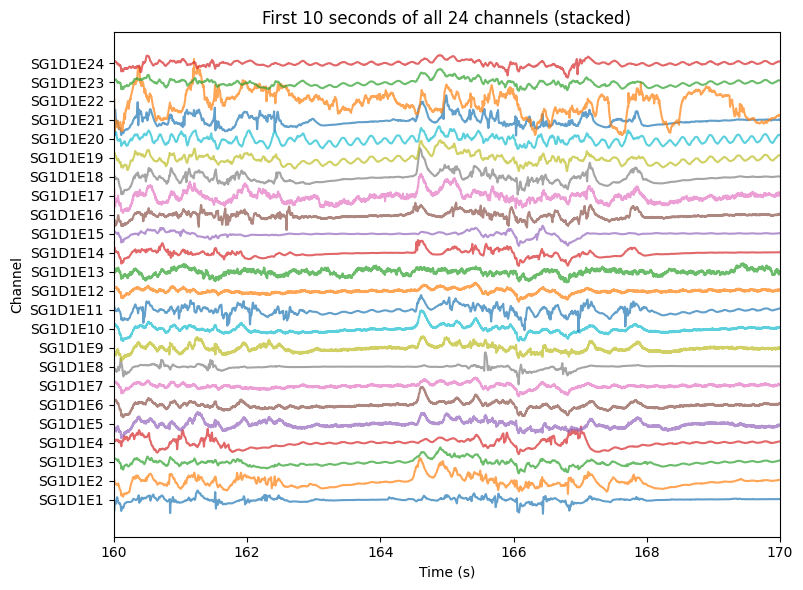

In [188]:
plot_signal(data_train, start=160, end=170, chann_names=channel_names)

In [199]:
pca_orig = PCA(whiten=True).fit(data_train)
X_train_proj = pca_orig.transform(data_train)
X_valid_proj = pca_orig.transform(data_valid)

**PCA whitening (`whiten=True`) is fit on `data_train` only**, then applied to both train and validation. sklearn’s PCA learns the mean, principal directions, and scaling from the training covariance; validation samples are projected with those same parameters. Any difference between splits in mean or covariance therefore shows up **after** whitening as non-identity covariance and non-flat spectra in a follow-up PCA.


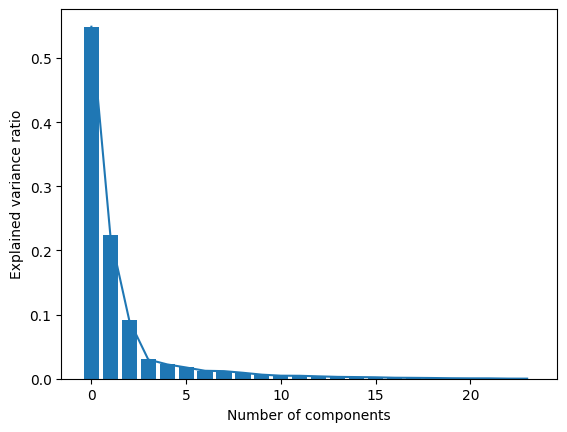

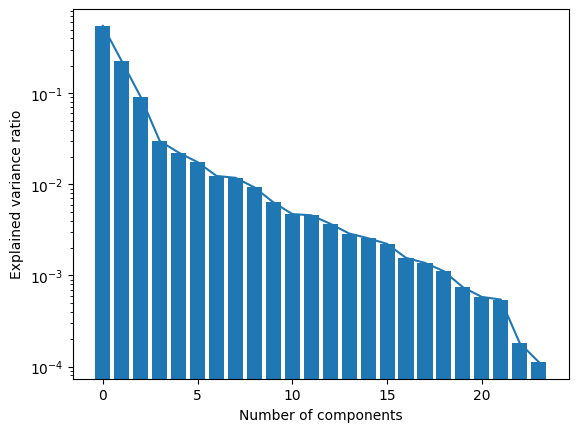

In [210]:
plot_pca_variance(pca_orig)
plot_pca_variance(pca_orig, log_scale=True)

The **explained variance ratio** decays quickly: channels are strongly correlated, so most variance lives in a few principal components. The ratios refer to this **first** PCA on the raw (per-split) data; they describe correlation structure before we inspect whitening on held-out time.


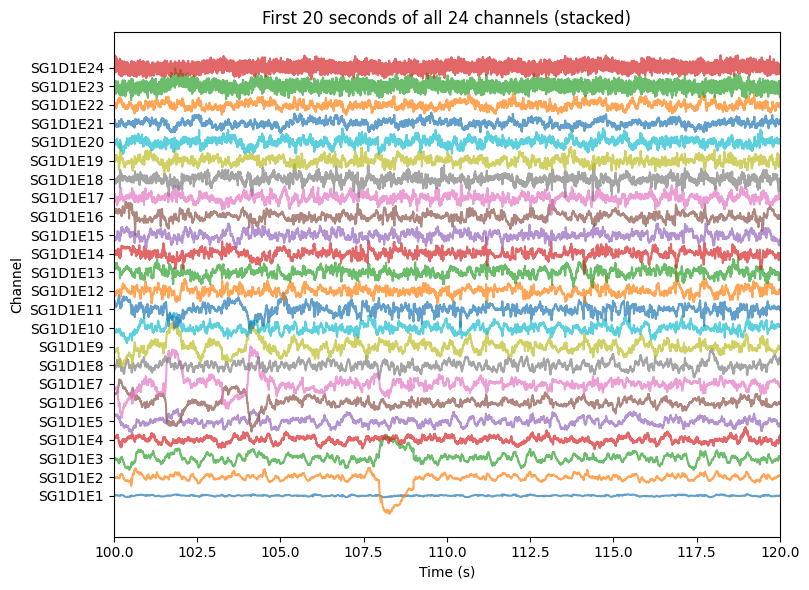

In [202]:
plot_signal(X_valid_proj, start=100, end=120, chann_names=channel_names)

The **validation** data passed through the **training-fitted** whitening transform still looks like uncorrelated, scaled components at a glance: high-index PCs are dominated by small-amplitude fluctuation. That does **not** mean the validation covariance in whitened space is exactly identity—we check that next.


### Covariance of whitened features

For ideal whitening **on the same distribution the PCA was fit on**, the covariance matrix of whitened features should be close to the identity. Comparing **train** vs. **validation** shows how well the training-derived transform generalizes to held-out time in this session.

The next two figures show whitened-feature covariance for **training**, then **validation**.


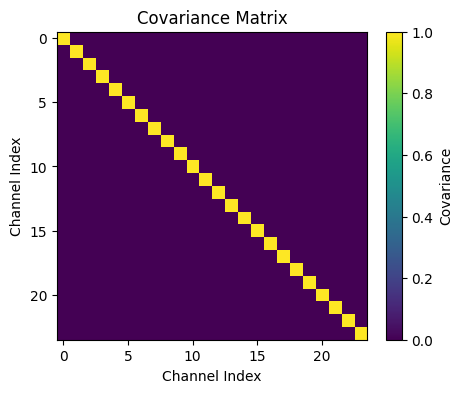

In [198]:
plot_covariance(np.cov(X_train_proj, rowvar=False))

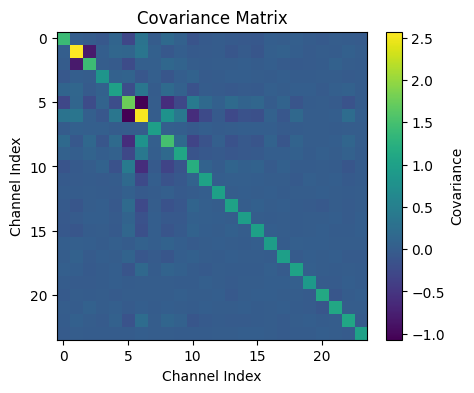

In [197]:
plot_covariance(np.cov(X_valid_proj, rowvar=False))

**Training:** covariance of `X_train_proj` is near identity—consistent with whitening fit on that split. **Validation:** `X_valid_proj` typically shows **off-diagonal structure** and **uneven** marginal variances: the eigenbasis and scalings were chosen for training statistics, not for validation. That mismatch is the same phenomenon that produces a non-flat second PCA on validation below.


### PCA on already-whitened data

We run a **second** PCA **without** additional whitening (`whiten=False` on train; default on validation where we only need explained variance). This is a diagnostic: if the data were exactly standard white in the PC basis, **all** components would carry equal variance and the explained-variance bar chart would be flat.


#### Training data

Second PCA on `X_train_proj` (whitened features from the **training**-fit transform).


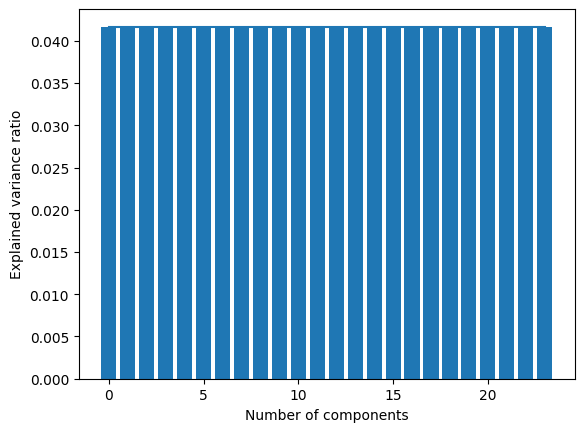

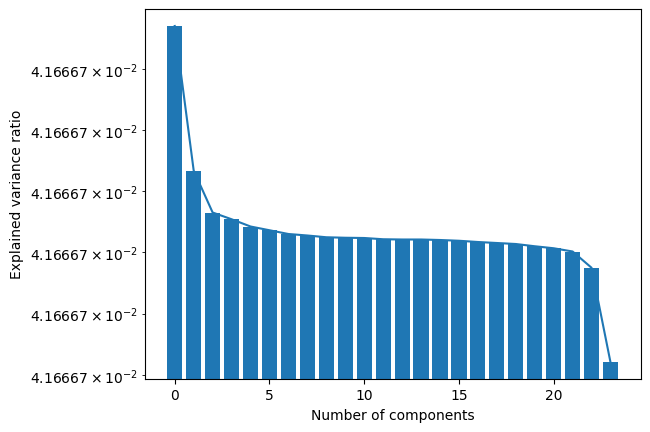

In [209]:
pca_nonorm = PCA(whiten=False).fit(X_train_proj)
plot_pca_variance(pca_nonorm)
plot_pca_variance(pca_nonorm, log_scale=True)

Here, we indeed see that the variance is perfectly flat. This is what we are expecting because we are whitening the data. By definition, this has to be the case as the variance of each component is being normalized to 1.

On **training**, the spectrum is **flat**: after the first whitening, each retained component has unit variance along the training principal axes, so a second PCA on that same matrix has no preferred direction. This is the definition of “white” **relative to the training fit**, not a statement about validation.


#### Validation data

Second PCA on `X_valid_proj`—the **validation** data transformed by the **training** whitening model.


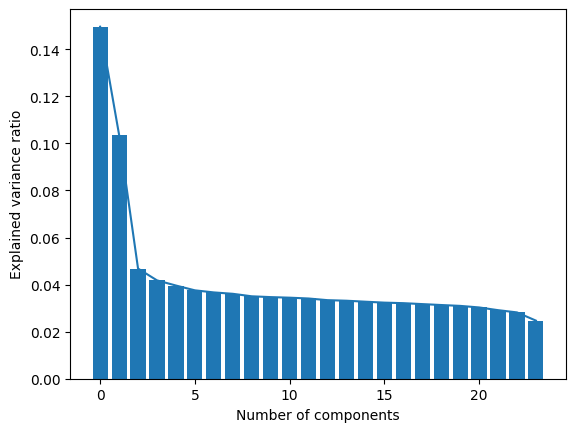

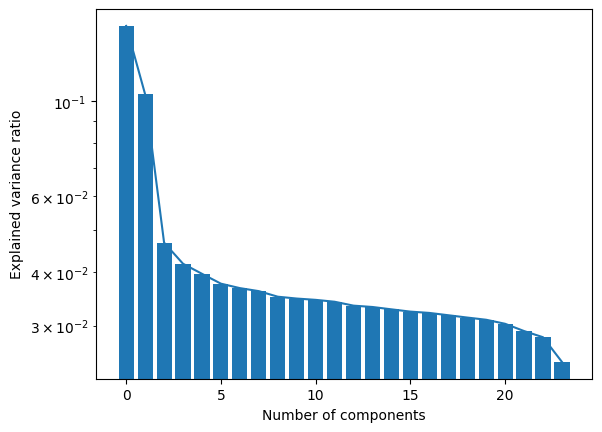

In [208]:
pca_nonorm = PCA(whiten=False).fit(X_valid_proj)
plot_pca_variance(pca_nonorm)
plot_pca_variance(pca_nonorm, log_scale=True)

This is not perfectly flat, but we can see that there are actually not that many non flat components. Basically, the whitening process is in fact being applied to the data, but given that it is fit only on the training data, the validation data is not perfectly exaplained by those same eigenvectors. 

On **validation**, the spectrum is **not** flat: a few components explain more variance than others. The first whitening step still **acts** on validation samples, but it was optimized for training; validation residuals in that basis need not be spherical. This is a concrete picture of **train–validation mismatch** after whitening—relevant for decoding pipelines that assume i.i.d. or whitened features across splits.


## Animation

A short 2D trajectory of the first two **whitened** validation PCs (first 1000 samples), mostly to visualize how the signal moves in the projected space.
